# 01 — Exploratory Data Analysis (EDA)

**Goal of this notebook:** understand the cleaned match dataset *before* building any
feature or model, and use the evidence to make three concrete decisions:

1. **Training window** — from which year is the data dense and relevant enough to learn from?
2. **Home advantage** — is it real and strong enough to deserve a feature?
3. **Outcome / goal structure** — what does a 'typical' international match look like?

We never assume; we look. Every decision below is backed by a chart or a number.

> Data source: cleaned `data/processed/matches_clean.csv` (produced by `src/data/clean.py`).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

# Robustly locate the project root (works no matter the working directory).
ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Project root:", ROOT)

Project root: C:\Dev\Worldcup


In [2]:
# Load the cleaned matches and derive a few helper columns.
df = pd.read_csv(ROOT / "data" / "processed" / "matches_clean.csv", parse_dates=["date"])

# 'neutral' may come back as strings depending on the CSV reader; coerce to real bool.
if df["neutral"].dtype == object:
    df["neutral"] = df["neutral"].map({"True": True, "False": False}).astype(bool)

df["year"] = df["date"].dt.year
df["total_goals"] = df["home_score"] + df["away_score"]
# Outcome from the home team's perspective: H(ome win) / D(raw) / A(way win).
df["result"] = np.select(
    [df["home_score"] > df["away_score"], df["home_score"] == df["away_score"]],
    ["H", "D"],
    default="A",
)

print(f"Matches: {len(df):,}")
print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")
df.head()

Matches: 49,405
Date range: 1872-11-30 -> 2026-06-10


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,total_goals,result
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,1872,0,D
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,1873,6,H
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,1874,3,H
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,1875,4,D
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,1876,3,H


## 1. How much data do we have over time?

Football data from the 1800s exists, but it is sparse and the game was a different sport.
If most matches are recent, training on the full history adds noise, not signal. Let's see
the number of matches per year.

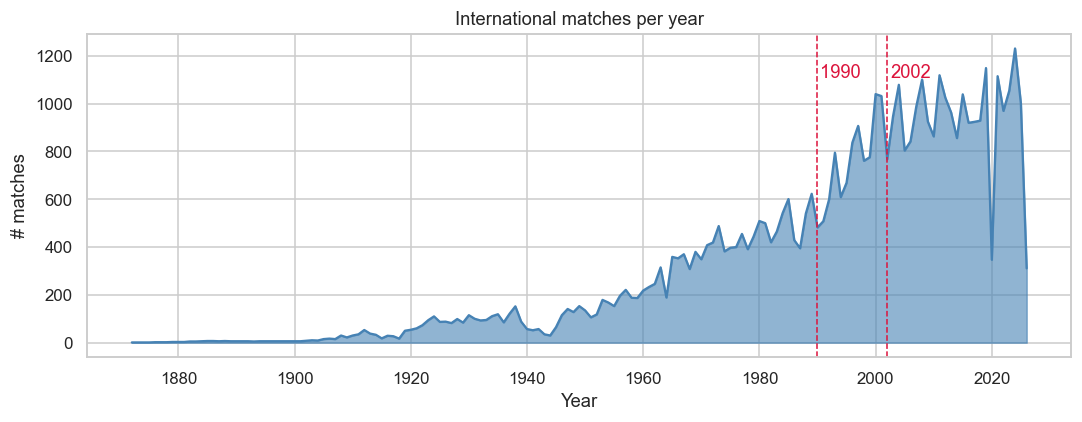

Matches from 1980 onward:  75.5%
Matches from 1990 onward:  65.4%
Matches from 2000 onward:  51.3%
Matches from 2002 onward:  47.1%
Matches from 2010 onward:  32.0%


In [3]:
per_year = df.groupby("year").size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(per_year.index, per_year.values, color="steelblue", alpha=0.6)
ax.plot(per_year.index, per_year.values, color="steelblue")
ax.set(title="International matches per year", xlabel="Year", ylabel="# matches")
for y in (1990, 2002):
    ax.axvline(y, color="crimson", ls="--", lw=1)
    ax.text(y + 0.5, per_year.max() * 0.9, str(y), color="crimson")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_matches_per_year.png", bbox_inches="tight")
plt.show()

for cut in (1980, 1990, 2000, 2002, 2010):
    share = (df["year"] >= cut).mean()
    print(f"Matches from {cut} onward: {share:6.1%}")

## 2. What does a typical match look like? (goals & outcomes)

Two things matter for modeling: how many goals are scored (the scale), and how often the
home team wins vs draws vs loses (the target distribution).

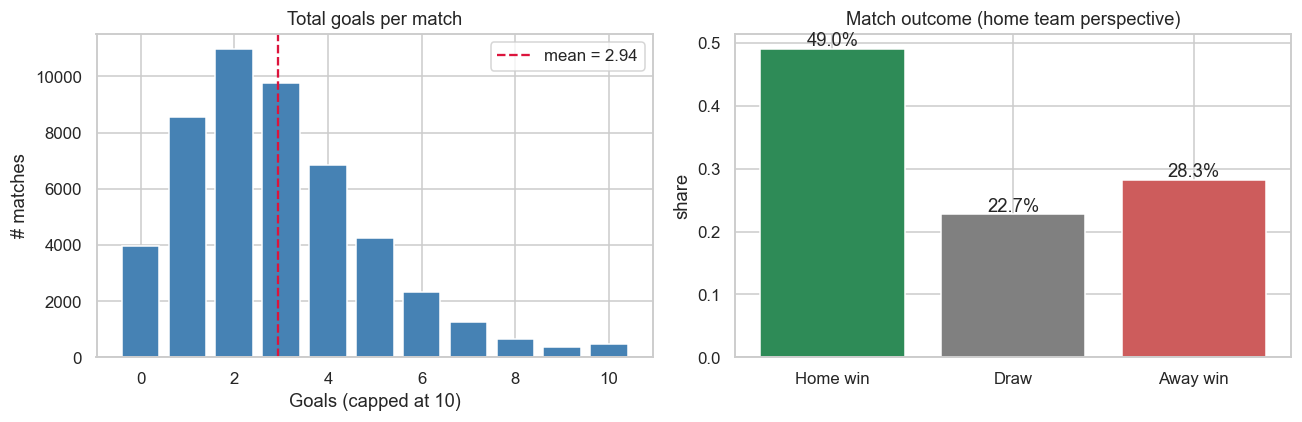

Avg home goals: 1.76 | Avg away goals: 1.18


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) Distribution of total goals per match.
counts = df["total_goals"].clip(upper=10).value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color="steelblue")
axes[0].set(title="Total goals per match", xlabel="Goals (capped at 10)", ylabel="# matches")
axes[0].axvline(df["total_goals"].mean(), color="crimson", ls="--",
                label=f"mean = {df['total_goals'].mean():.2f}")
axes[0].legend()

# (b) Outcome distribution (home perspective).
res = df["result"].value_counts(normalize=True).reindex(["H", "D", "A"])
axes[1].bar(["Home win", "Draw", "Away win"], res.values,
            color=["seagreen", "gray", "indianred"])
for i, v in enumerate(res.values):
    axes[1].text(i, v + 0.005, f"{v:.1%}", ha="center")
axes[1].set(title="Match outcome (home team perspective)", ylabel="share")

fig.tight_layout()
fig.savefig(FIG_DIR / "02_goals_and_outcomes.png", bbox_inches="tight")
plt.show()

print(f"Avg home goals: {df['home_score'].mean():.2f} | Avg away goals: {df['away_score'].mean():.2f}")

## 3. Is home advantage real?

This is the single most important contextual feature in football. But many international
matches (tournaments, World Cups) are played on **neutral** ground. If we split by the
`neutral` flag, the home-field effect should *shrink* on neutral venues — that would prove
the effect is real and that the flag is informative.

,home_goals,away_goals,home_win,draw,away_win,n
neutral,,,,,,
Has host (non-neutral),1.79,1.11,50.7%,22.9%,26.4%,"36,347"
Neutral venue,1.67,1.37,44.2%,22.4%,33.4%,"13,058"


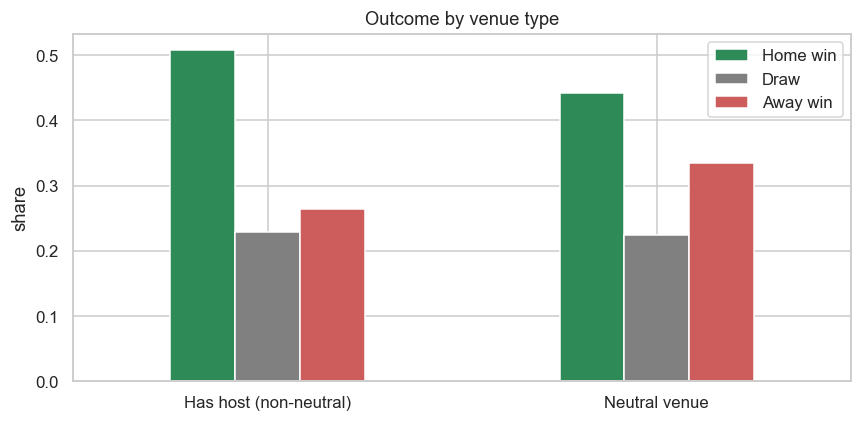

In [5]:
summary = (
    df.groupby("neutral")
      .agg(home_goals=("home_score", "mean"),
           away_goals=("away_score", "mean"),
           home_win=("result", lambda s: (s == "H").mean()),
           draw=("result", lambda s: (s == "D").mean()),
           away_win=("result", lambda s: (s == "A").mean()),
           n=("result", "size"))
)
summary.index = summary.index.map({False: "Has host (non-neutral)", True: "Neutral venue"})
display(summary.style.format({"home_goals": "{:.2f}", "away_goals": "{:.2f}",
                              "home_win": "{:.1%}", "draw": "{:.1%}",
                              "away_win": "{:.1%}", "n": "{:,}"}))

# Visualize the home-win rate gap.
fig, ax = plt.subplots(figsize=(8, 4))
summary[["home_win", "draw", "away_win"]].plot(kind="bar", ax=ax,
    color=["seagreen", "gray", "indianred"])
ax.set(title="Outcome by venue type", ylabel="share", xlabel="")
ax.set_xticklabels(summary.index, rotation=0)
ax.legend(["Home win", "Draw", "Away win"])
fig.tight_layout()
fig.savefig(FIG_DIR / "03_home_advantage.png", bbox_inches="tight")
plt.show()

## 4. Do the 2026 World Cup teams have enough history?

The model can only rate a team it has seen play. Let's check how many matches each of the
48 qualified teams has in the **modern era (2010+)**. A team with very few matches will have
a noisy rating — worth knowing before we trust its prediction.

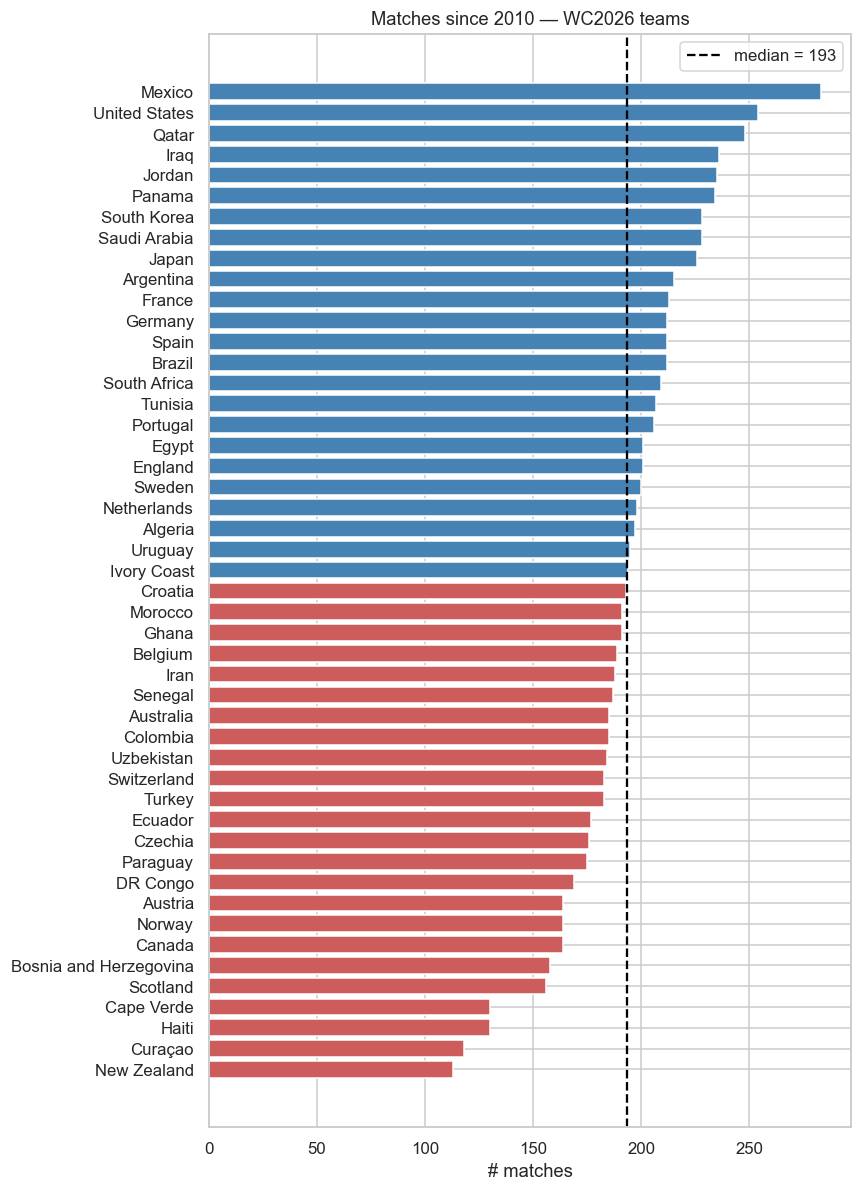

Teams with fewest matches since 2010:
New Zealand               113
Curaçao                   118
Haiti                     130
Cape Verde                130
Scotland                  156
Bosnia and Herzegovina    158


In [6]:
groups = pd.read_csv(ROOT / "data" / "external" / "wc2026_groups.csv")
wc_teams = set(groups["team"])

recent = df[df["year"] >= 2010]
appearances = pd.concat([recent["home_team"], recent["away_team"]])
counts = appearances[appearances.isin(wc_teams)].value_counts()
# Ensure every WC team appears, even with 0 matches.
counts = counts.reindex(sorted(wc_teams)).fillna(0).astype(int).sort_values()

fig, ax = plt.subplots(figsize=(8, 11))
colors = ["indianred" if c < counts.median() else "steelblue" for c in counts.values]
ax.barh(counts.index, counts.values, color=colors)
ax.set(title="Matches since 2010 — WC2026 teams", xlabel="# matches")
ax.axvline(counts.median(), color="black", ls="--", label=f"median = {int(counts.median())}")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "04_team_coverage.png", bbox_inches="tight")
plt.show()

print("Teams with fewest matches since 2010:")
print(counts.head(6).to_string())

## Conclusions & decisions

These findings drive the next stages (feature engineering & modeling):

- **Training window — use matches from 2002 onward.** The per-year chart shows data becomes
  dense and stable in the modern era; pre-1990 matches are sparse and reflect a different
  game. 2002 keeps ~20+ years of dense data (a large sample) while staying relevant. *Elo
  itself will still be warmed up using the full history* so ratings are not cold-started.
- **Home advantage is real and must be a feature.** Home-win rate is markedly higher on
  non-neutral venues than on neutral ones. Since the World Cup is played on neutral-ish
  ground (hosts USA/Canada/Mexico aside), the `neutral` flag is informative.
- **Outcomes are imbalanced (home win > away win > draw)** and goals are low-scoring
  (mean ≈ 2.7 total). This justifies a 3-class classifier and reminds us draws are the
  hardest class to predict.
- **A few qualified teams have thin recent histories** (flagged above). Their ratings will
  be noisier; we'll keep this caveat when reading final probabilities.

➡️ **Next:** `src/features/elo.py` — compute Elo ratings over the full history, then build
match-level features for the modern window.